# Exercício 2 — Geração e análise de redes com NetLogo

Este notebook demonstra os mesmos tipos de rede disponíveis no modelo `NW General Examples.nlogo` do NetLogo,
usando **networkx** para gerar, visualizar e calcular métricas de redes artificiais.

> **Material necessário:** `NWGeneralExamplesArquivo.NLOGO` (na mesma pasta) para abrir no NetLogo.

## 1. Geradores de rede

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

N_NOS = 50
SEED = 42

geradores = {
    'Barabasi-Albert (pref. attachment)': nx.barabasi_albert_graph(N_NOS, 2, seed=SEED),
    'Erdos-Renyi (aleatorio)': nx.erdos_renyi_graph(N_NOS, 0.08, seed=SEED),
    'Anel (circular)': nx.cycle_graph(N_NOS),
    'Estrela': nx.star_graph(N_NOS - 1),
    'Roda': nx.wheel_graph(N_NOS),
    'Small world (Watts-Strogatz)': nx.watts_strogatz_graph(N_NOS, 4, 0.3, seed=SEED),
    'Grade 2D': nx.grid_2d_graph(7, 7),
}

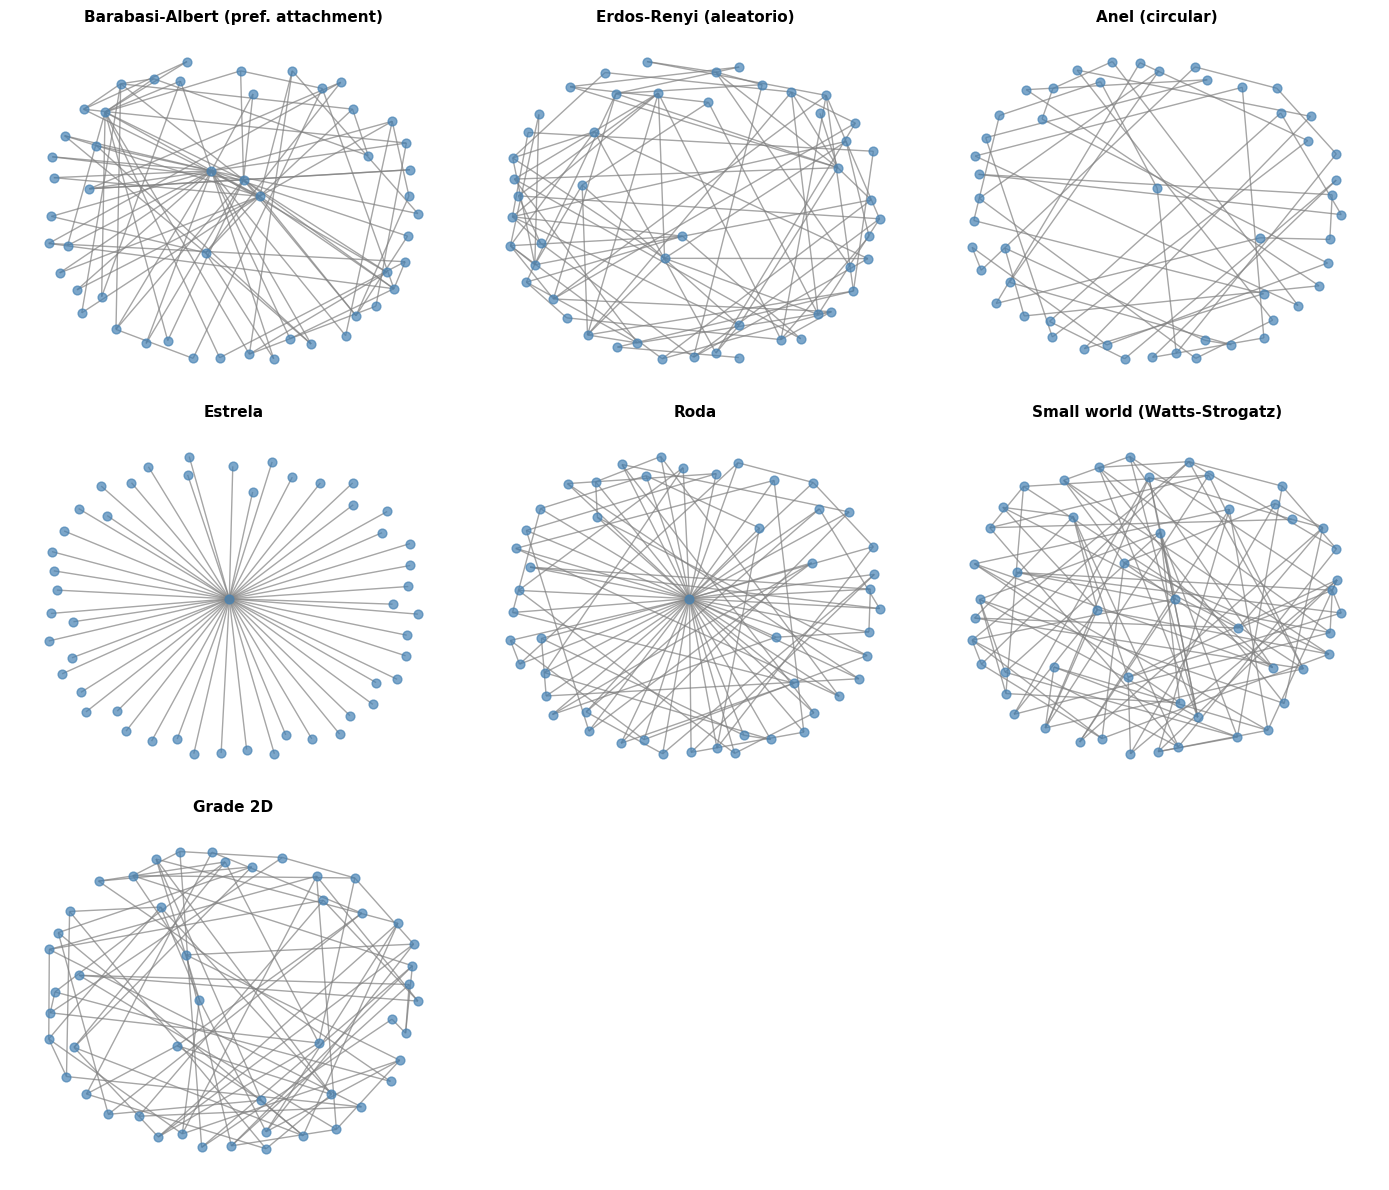

In [36]:
def desenhar_rede(G, titulo, ax):
    pos = nx.spring_layout(G, seed=SEED, k=2)
    nx.draw(G, pos, ax=ax, node_size=40, node_color='steelblue',
            edge_color='gray', alpha=0.7, with_labels=False)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, (nome, G) in enumerate(geradores.items()):
    G_und = G.to_undirected() if G.is_directed() else G
    desenhar_rede(G_und, nome, axes[i])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
import os
_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula05')
os.makedirs(PASTA_AULA, exist_ok=True)
plt.savefig(os.path.join(PASTA_AULA, 'aula_05_exercicio_02_redes.png'), dpi=150, bbox_inches='tight')


## 2. Métricas das redes

In [37]:
def calcular_metricas(G):
    G_und = G.to_undirected() if G.is_directed() else G
    n = G_und.number_of_nodes()
    if n < 2:
        return {}
    graus = [d for _, d in G_und.degree()]
    betweenness = nx.betweenness_centrality(G_und)
    closeness = nx.closeness_centrality(G_und)
    componentes = nx.number_connected_components(G_und)
    diametro = None
    if componentes == 1:
        try:
            diametro = nx.diameter(G_und)
        except nx.NetworkXError:
            pass
    max_clique = None
    if n <= 100:
        try:
            cliques = list(nx.find_cliques(G_und))
            max_clique = max(len(c) for c in cliques) if cliques else 0
        except nx.NetworkXError:
            pass
    return {
        'Nos': n,
        'Arestas': G_und.number_of_edges(),
        'Grau_medio': round(np.mean(graus), 2),
        'Cluster_medio': round(nx.average_clustering(G_und), 4),
        'Betweenness_media': round(np.mean(list(betweenness.values())), 4),
        'Closeness_media': round(np.mean(list(closeness.values())), 4),
        'Componentes': componentes,
        'Diametro': diametro,
        'Maior_clique': max_clique,
    }

linhas = []
for nome, G in geradores.items():
    m = calcular_metricas(G)
    m['Rede'] = nome
    linhas.append(m)

df_metricas = pd.DataFrame(linhas)
df_metricas = df_metricas[['Rede'] + [c for c in df_metricas.columns if c != 'Rede']]
display(df_metricas)

,Rede,Nos,Arestas,Grau_medio,Cluster_medio,Betweenness_media,Closeness_media,Componentes,Diametro,Maior_clique
0,Barabasi-Albert (pref. attachment),50,96,3.84,0.2609,0.0312,0.4079,1,5,3
1,Erdos-Renyi (aleatorio),50,90,3.60,0.0273,0.0428,0.3330,1,6,3
2,Anel (circular),50,50,2.00,0.0000,0.2449,0.0784,1,25,2
3,Estrela,50,49,1.96,0.0000,0.0200,0.5151,1,2,2
4,Roda,50,98,3.92,0.6542,0.0192,0.5255,1,2,3
5,Small world (Watts-Strogatz),50,100,4.00,0.1993,0.0430,0.3280,1,6,3
6,Grade 2D,49,84,3.43,0.0000,0.0780,0.2193,1,12,2


## 3. Comparação de layouts

Testando com uma rede **small world** (Watts-Strogatz).

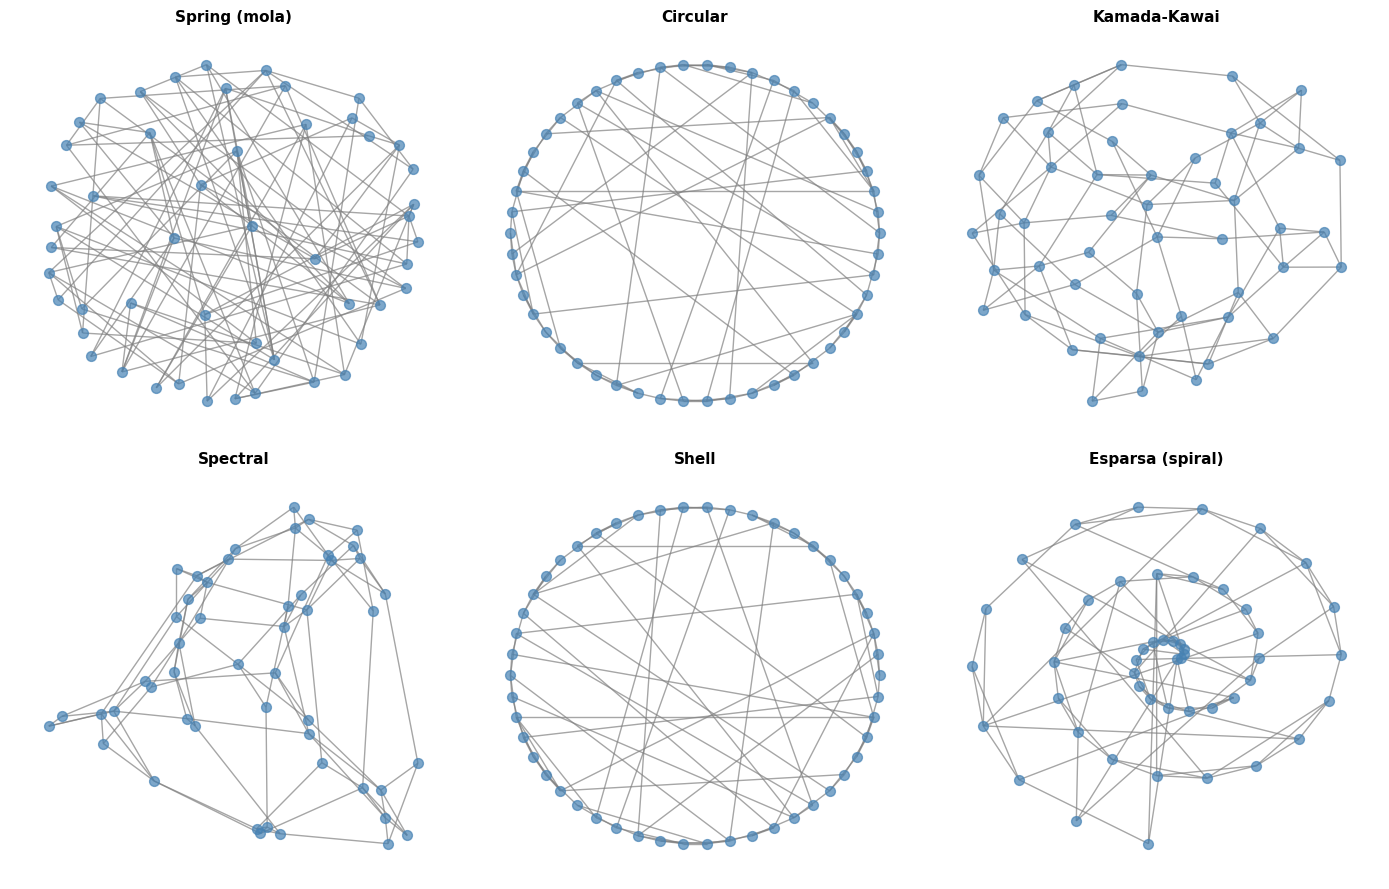

In [38]:
G_sw = nx.watts_strogatz_graph(N_NOS, 4, 0.3, seed=SEED)

layouts_dict = {
    'Spring (mola)': nx.spring_layout(G_sw, seed=SEED, k=2),
    'Circular': nx.circular_layout(G_sw),
    'Kamada-Kawai': nx.kamada_kawai_layout(G_sw),
    'Spectral': nx.spectral_layout(G_sw),
    'Shell': nx.shell_layout(G_sw),
    'Esparsa (spiral)': nx.spiral_layout(G_sw),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (nome, pos) in enumerate(layouts_dict.items()):
    nx.draw(G_sw, pos, ax=axes[i], node_size=50, node_color='steelblue',
            edge_color='gray', alpha=0.7, with_labels=False)
    axes[i].set_title(nome, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula05')
os.makedirs(PASTA_AULA, exist_ok=True)
plt.savefig(os.path.join(PASTA_AULA, 'aula_05_exercicio_02_layouts.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 4. Perguntas

### Pergunta 2a

> Em geral, diferentes layouts funcionam melhor para diferentes tipos de gráficos. Você pode experimentar todas as combinações de gráfico/layout? Qual layout você prefere para cada tipo de gráfico? Por quê?

In [39]:
resposta_pergunta_2a = '''
(A IA preenchera esta resposta na secao "Gerar respostas com IA".)
'''

### Pergunta 2b

> Experimente o layout de mola com uma rede 2D em forma de treliça, com a opção WRAP desativada. Como fica? Agora experimente com a opção WRAP ativada. Você consegue explicar a diferença?

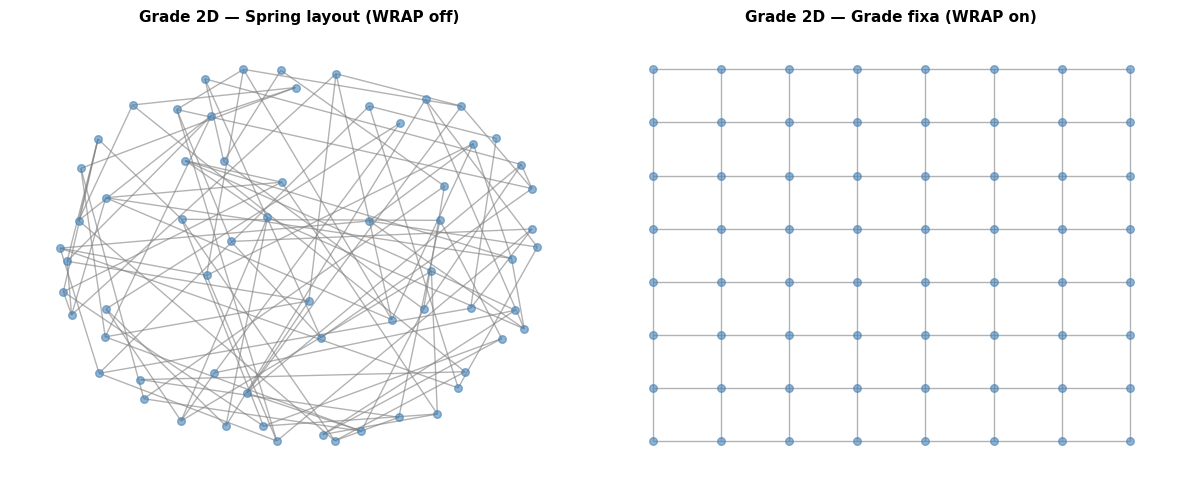

In [40]:
G_grade = nx.grid_2d_graph(8, 8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

pos_nowrap = nx.spring_layout(G_grade, seed=SEED, k=1.5)
nx.draw(G_grade, pos_nowrap, ax=ax1, node_size=30, node_color='steelblue',
        edge_color='gray', alpha=0.6, with_labels=False)
ax1.set_title('Grade 2D — Spring layout (WRAP off)', fontsize=11, fontweight='bold')
ax1.axis('off')

pos_wrap = {n: (n[1], -n[0]) for n in G_grade.nodes()}
nx.draw(G_grade, pos_wrap, ax=ax2, node_size=30, node_color='steelblue',
        edge_color='gray', alpha=0.6, with_labels=False)
ax2.set_title('Grade 2D — Grade fixa (WRAP on)', fontsize=11, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula05')
os.makedirs(PASTA_AULA, exist_ok=True)
plt.savefig(os.path.join(PASTA_AULA, 'aula_05_exercicio_02_wrap.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [41]:
resposta_pergunta_2b = '''
(A IA preenchera esta resposta na secao "Gerar respostas com IA".)
'''

### Pergunta 2c

> Gere uma rede de mundo pequeno com um expoente de agrupamento baixo (ex.: 0,1). Qual é o tamanho da maior clique maximal? Agora tente com um expoente grande (ex.: 10,0). Qual é o tamanho? Tente várias vezes. Você consegue identificar algum padrão? E se você aumentar o número de linhas e colunas?

In [42]:
def maior_clique_ws(n_nos, k_vizinhos, prob_reconexao, seed):
    G = nx.watts_strogatz_graph(n_nos, k_vizinhos, prob_reconexao, seed=seed)
    cliques = list(nx.find_cliques(G))
    max_clique = max(len(c) for c in cliques) if cliques else 0
    clustering = nx.average_clustering(G)
    return max_clique, round(clustering, 4)

print('Rede small world (50 nos, k=4) — variacao da probabilidade de reconexao:\n')
resultados_clique = []
for prob in [0.1, 0.3, 0.5, 0.7, 0.9]:
    max_c, clust = maior_clique_ws(50, 4, prob, SEED)
    resultados_clique.append({'Probabilidade': prob, 'Maior_clique': max_c, 'Cluster_medio': clust})
    print(f'  prob={prob:.1f}  |  maior clique = {max_c:2d}  |  cluster medio = {clust}')

print('\nRede small world — aumentando o tamanho (prob=0.3, k=4):\n')
resultados_tamanho = []
for n_nos in [20, 50, 100, 200]:
    max_c, clust = maior_clique_ws(n_nos, 4, 0.3, SEED)
    resultados_tamanho.append({'N_nos': n_nos, 'Maior_clique': max_c, 'Cluster_medio': clust})
    print(f'  n={n_nos:3d}  |  maior clique = {max_c:2d}  |  cluster medio = {clust}')

df_clique = pd.DataFrame(resultados_clique)
df_tamanho = pd.DataFrame(resultados_tamanho)

Rede small world (50 nos, k=4) — variacao da probabilidade de reconexao:

  prob=0.1  |  maior clique =  4  |  cluster medio = 0.3433
  prob=0.3  |  maior clique =  3  |  cluster medio = 0.1993
  prob=0.5  |  maior clique =  3  |  cluster medio = 0.1376
  prob=0.7  |  maior clique =  3  |  cluster medio = 0.1066
  prob=0.9  |  maior clique =  3  |  cluster medio = 0.0558

Rede small world — aumentando o tamanho (prob=0.3, k=4):

  n= 20  |  maior clique =  3  |  cluster medio = 0.2195
  n= 50  |  maior clique =  3  |  cluster medio = 0.1993
  n=100  |  maior clique =  3  |  cluster medio = 0.2026
  n=200  |  maior clique =  3  |  cluster medio = 0.1727


In [43]:
resposta_pergunta_2c = '''
(A IA preenchera esta resposta na secao "Gerar respostas com IA".)
'''

## 5. Gerar respostas com IA

Execute a célula abaixo para que a IA analise os dados gerados e preencha automaticamente
as respostas das perguntas 2a, 2b e 2c. Você pode editar os resultados depois se quiser.

In [44]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

def consultar(prompt):
    payload = {
        'model': MODELO,
        'messages': [{'role': 'user', 'content': prompt}],
        'stream': False,
        'options': {'temperature': 0.3, 'top_p': 0.9, 'num_predict': 600},
    }
    req = Request(
        BASE_URL + '/api/chat',
        data=json.dumps(payload).encode('utf-8'),
        headers=headers,
        method='POST',
    )
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    return dados.get('message', {}).get('content', '').strip()

# --- Pergunta 2a ---
print('=== Pergunta 2a ===')
prompt_2a = f'''Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 3 paragrafos).

Pergunta: Em geral, diferentes layouts funcionam melhor para diferentes tipos de graficos.
Qual layout voce prefere para cada tipo de grafico? Por que?

Dados das redes geradas:
{df_metricas.to_markdown(index=False)}

Layouts disponiveis: Spring (mola), Circular, Kamada-Kawai, Spectral, Shell, Esparsa (spiral).'''
try:
    r = consultar(prompt_2a)
    if r:
        resposta_pergunta_2a = r
        print('OK')
except Exception as e:
    print(f'Erro: {e}')

# --- Pergunta 2b ---
print('\n=== Pergunta 2b ===')
prompt_2b = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 2 paragrafos).

Pergunta: Experimente o layout de mola com uma rede 2D em forma de trelica, com a opcao
WRAP desativada. Como fica? Agora experimente com a opcao WRAP ativada.
Voce consegue explicar a diferenca?

Contexto: No grafico gerado, WRAP off mostra a grade com nos posicionados livremente
pelo algoritmo de mola (spring layout), enquanto WRAP on mostra a grade fixa com nos
em posicoes regulares de matriz (coordenadas x,y).'''
try:
    r = consultar(prompt_2b)
    if r:
        resposta_pergunta_2b = r
        print('OK')
except Exception as e:
    print(f'Erro: {e}')

# --- Pergunta 2c ---
print('\n=== Pergunta 2c ===')
prompt_2c = f'''Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 3 paragrafos).

Pergunta: Gere uma rede de mundo pequeno com um expoente de agrupamento baixo (ex.: 0,1).
Qual e o tamanho da maior clique maximal? Agora tente com um expoente grande (ex.: 10,0).
Qual e o tamanho? Tente varias vezes. Voce consegue identificar algum padrao?
E se voce aumentar o numero de linhas e colunas?

Dados medidos:
Variacao com probabilidade de reconexao (prob=0.1 a 0.9):
{df_clique.to_markdown(index=False)}

Variacao com tamanho da rede (n=20 a 200, prob=0.3):
{df_tamanho.to_markdown(index=False)}'''
try:
    r = consultar(prompt_2c)
    if r:
        resposta_pergunta_2c = r
        print('OK')
except Exception as e:
    print(f'Erro: {e}')

print('\nRespostas geradas! Edite-as manualmente se necessario.')
print('\n--- Resposta 2a ---')
print(resposta_pergunta_2a)
print('\n--- Resposta 2b ---')
print(resposta_pergunta_2b)
print('\n--- Resposta 2c ---')
print(resposta_pergunta_2c)

=== Pergunta 2a ===
OK

=== Pergunta 2b ===
OK

=== Pergunta 2c ===
OK

Respostas geradas! Edite-as manualmente se necessario.

--- Resposta 2a ---
Para **redes densas ou com alta conectividade** (como a *Small World* ou *Rodas*), o **layout *Kamada-Kawai*** é ideal. Ele preserva distâncias naturais entre nós, mantendo a hierarquia de conectividade e evitando sobreposições desnecessárias, o que facilita a visualização de padrões locais (como clusters ou pontes de alta entrelaçamento). Além disso, é eficiente para redes com **diametro pequeno**, como a *Estrela* ou *Anel*, onde a disposição circular ou radial é mais intuitiva.

Para **redes esparsas ou com baixa densidade** (como *Barabasi-Albert* ou *Erdos-Renyi*), o **layout *Spectral*** ou *Spring* são excelentes opções. O *Spectral* aproveita as propriedades matemáticas da matriz de adjacência para organizar nós de forma hierárquica, destacando estruturas como graus irregulares ou comunidades implícitas. Já o *Spring* (mola) é mais 

## 6. Explorando no NetLogo

1. Baixe e instale o NetLogo em [ccl.northwestern.edu/netlogo](https://ccl.northwestern.edu/netlogo/)
2. Abra o arquivo `NWGeneralExamplesArquivo.NLOGO`
3. Leia a aba **Informacao** para descricao detalhada
4. Na aba **Interface**, experimente geradores, layouts e metricas
5. Compare com as visualizacoes geradas pelo Python

## 7. Gerar Markdown para Moodle

Execute a celula abaixo apos ter gerado as respostas com IA (ou editado manualmente).
Ela salva tudo em `work/tarefas_moodle/`.

In [45]:
import os
import subprocess
from datetime import datetime

_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula05')
os.makedirs(PASTA_AULA, exist_ok=True)

agora = datetime.now().strftime('%Y-%m-%d %H:%M')

PATH_MD = os.path.join(PASTA_AULA, 'aula_05_exercicio_02.md')
with open(PATH_MD, 'w', encoding='utf-8') as f:
    f.write('# Aula 05 — Exercicio 02: Geracao e analise de redes com NetLogo\n\n')
    f.write(f'_Executado em: {agora}_\n\n')
    f.write('---\n\n')
    f.write('## Metricas comparativas\n\n')
    f.write(df_metricas.to_markdown(index=False))
    f.write('\n\n')
    f.write('---\n\n')
    f.write('## Variacao de cliques com probabilidade de reconexao\n\n')
    f.write(df_clique.to_markdown(index=False))
    f.write('\n\n')
    f.write('## Variacao de cliques com tamanho da rede\n\n')
    f.write(df_tamanho.to_markdown(index=False))
    f.write('\n\n')
    f.write('---\n\n')
    f.write('## Redes geradas\n\n')
    f.write('![Tipos de rede](aula_05_exercicio_02_redes.png)\n\n')
    f.write('---\n\n')
    f.write('## Comparacao de layouts\n\n')
    f.write('![Layouts](aula_05_exercicio_02_layouts.png)\n\n')
    f.write('---\n\n')
    f.write('## Efeito WRAP na grade 2D\n\n')
    f.write('![WRAP on/off](aula_05_exercicio_02_wrap.png)\n\n')
    f.write('---\n\n')
    f.write('## Respostas do aluno\n\n')
    f.write('### Pergunta 2a\n\n')
    f.write(resposta_pergunta_2a.strip())
    f.write('\n\n')
    f.write('### Pergunta 2b\n\n')
    f.write(resposta_pergunta_2b.strip())
    f.write('\n\n')
    f.write('### Pergunta 2c\n\n')
    f.write(resposta_pergunta_2c.strip())
    f.write('\n')

PATH_PDF = PATH_MD.replace('.md', '.pdf')
if shutil.which('pandoc'):
    subprocess.run(['pandoc', PATH_MD, '-o', PATH_PDF, '--pdf-engine=xelatex', '--resource-path', PASTA_AULA, '-V', 'mainfont=DejaVu Serif'], check=True)
else:
    print('Aviso: pandoc nao instalado. Execute ./setup.sh para instalar.')
print(f'Markdown: {os.path.abspath(PATH_MD)}')
print(f'PDF:      {os.path.abspath(PATH_PDF)}')

Markdown: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula05/aula_05_exercicio_02.md
PDF:      /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula05/aula_05_exercicio_02.pdf
